# 01 — Детектив: анализ качества данных

**Датасет:** `data/processed/perfumes_merged.csv`  
**Задача:** Классификация сентимента отзывов (текст + числовые фичи)  
**Цель ноутбука:** Найти все проблемы качества данных и оценить их влияние на ML-пайплайн.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Добавляем scripts/ в путь
sys.path.insert(0, str(Path('..') / 'scripts'))
from quality_utils import (
    detect_encoding_issues, detect_short_texts,
    detect_duplicate_reviewers, detect_rating_leakage,
    compute_quality_score, save_report, REPORTS_DIR
)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/processed/perfumes_merged.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (931, 10)


,perfume_name,brand,rating,votes,top_notes,middle_notes,base_notes,reviewer,review_date,review_text
0,Acqua di Parma Colonia,Acqua di Parma,4.01,1498,"Ozonic notes, Bergamot, Orange, Petitgrain","Narcissus, Jasmine Sambac, Coriander","White Musk, Cedar, Patchouli",165599 yrok27,14.08.2024,"Начну отзыв с того, что я не являюсь поклонник..."
1,Acqua di Parma Colonia,Acqua di Parma,4.01,1498,"Ozonic notes, Bergamot, Orange, Petitgrain","Narcissus, Jasmine Sambac, Coriander","White Musk, Cedar, Patchouli",390523 parfuminka,13.07.2024,Для меня это аромат Италии! Люблю покупать дух...
2,Acqua di Parma Colonia,Acqua di Parma,4.01,1498,"Ozonic notes, Bergamot, Orange, Petitgrain","Narcissus, Jasmine Sambac, Coriander","White Musk, Cedar, Patchouli",397993 aruru,19.05.2024,"Великолепный классический освежающий, зеленый,..."


## 2. Базовая статистика

In [3]:
print('=== Типы данных ===')
print(df.dtypes)
print()
print('=== Пропуски ===')
print(df.isnull().sum())
print()
print('=== Дубликаты строк ===')
print(f'Полных дубликатов: {df.duplicated().sum()}')
print()
print('=== Уникальные парфюмы ===')
print(f'{df["perfume_name"].nunique()} парфюмов, {df["brand"].nunique()} брендов')
print(df.groupby('perfume_name').size().rename('reviews').to_frame())

=== Типы данных ===
perfume_name     object
brand            object
rating          float64
votes             int64
top_notes        object
middle_notes     object
base_notes       object
reviewer         object
review_date      object
review_text      object
dtype: object

=== Пропуски ===
perfume_name    0
brand           0
rating          0
votes           0
top_notes       0
middle_notes    0
base_notes      0
reviewer        0
review_date     0
review_text     0
dtype: int64

=== Дубликаты строк ===
Полных дубликатов: 0

=== Уникальные парфюмы ===
8 парфюмов, 8 брендов
                           reviews
perfume_name                      
Acqua di Parma Colonia          56
Aspen For Men                   54
Black Pearls                    74
By the Fireplace               203
Chanel No 5 Eau de Parfum      208
Cuoium                         201
Dioressence                     79
The One Gentleman               56


## 3. Проблема 1: Encoding-порча в текстах отзывов

In [4]:
enc_mask = detect_encoding_issues(df['review_text'])
print(f'Отзывов с encoding-порчей: {enc_mask.sum()} ({enc_mask.mean()*100:.1f}%)')
print()
print('Примеры поражённых отзывов:')
for _, row in df[enc_mask].head(5).iterrows():
    print(f'  [{row["perfume_name"]}] {repr(row["review_text"][:80])}')

Отзывов с encoding-порчей: 21 (2.3%)

Примеры поражённых отзывов:
  [By the Fireplace] 'Вот я снова не могу, в противовес "большинству", поймать вообще никакой ванили, '
  [By the Fireplace] '\\-Кашмеран перуанский бальзам. Гвоздика и пряности. Очень приятный аромат. Кашта'
  [By the Fireplace] 'Аромат стартует пьянящим шлейфом горящей древесины, где мягкие ноты каштанов и д'
  [By the Fireplace] 'Этот аромат напомнил мне об одном эпизоде из детства: лето, у бабушки в деревне.'
  [By the Fireplace] 'Костёр чувствую только в первые минуты нанесения, дальше только каштаны - много '


## 4. Проблема 2: Слишком короткие отзывы

In [5]:
df['review_len'] = df['review_text'].str.len()
short_mask = detect_short_texts(df['review_text'], min_len=50)
short_only = short_mask & ~enc_mask  # без уже поражённых encoding

print(f'Коротких отзывов (<50 симв.), без encoding-порчи: {short_only.sum()} ({short_only.mean()*100:.1f}%)')
print()
print('Примеры:')
for _, row in df[short_only].head(8).iterrows():
    print(f'  [{len(row["review_text"]):3d} симв.] {repr(row["review_text"][:80])}')

Коротких отзывов (<50 симв.), без encoding-порчи: 27 (2.9%)

Примеры:
  [ 35 симв.] 'Есть ДНК от Egoiste Platinum Chanel'
  [ 24 симв.] 'Истинное красивое ретро.'
  [ 36 симв.] 'Замечательная весенне-летняя зелень.'
  [ 45 симв.] 'Есть и стойкость, и шлейф. Нет зелени и елок.'
  [ 38 симв.] 'сладко дымно кожано. паленая карамель?'
  [ 49 симв.] 'Невозможная вкуснятина, но до обидного нестойкий.'
  [ 17 симв.] 'Сосиски в тесте))'
  [ 49 симв.] 'Сладкий, дымный, уютный. Особенно порадует зимой!'


## 5. Проблема 3: Дублирование рецензентов

In [6]:
dup_mask = detect_duplicate_reviewers(df, 'reviewer')
print(f'Строк с рецензентом, оставившим >1 отзыва: {dup_mask.sum()} ({dup_mask.mean()*100:.1f}%)')

dup_counts = df['reviewer'].value_counts()
dup_counts = dup_counts[dup_counts > 1]
print(f'Уникальных повторных рецензентов: {len(dup_counts)}')
print()
print('Топ-10 рецензентов по количеству отзывов:')
print(dup_counts.head(10))

Строк с рецензентом, оставившим >1 отзыва: 151 (16.2%)
Уникальных повторных рецензентов: 65

Топ-10 рецензентов по количеству отзывов:
reviewer
308435 SereginS           7
354265 toporlyando        7
388746 Yev                4
172693 торбернит          3
22486 Attar               3
300143 GG77               3
116003 Любовь.Данилова    3
273328 PrincesKris        3
238694 tamarasurenkova    3
214176 Инс                3
Name: count, dtype: int64


## 6. Проблема 4: Rating — агрегат уровня парфюма

In [7]:
is_leakage = detect_rating_leakage(df, 'perfume_name', 'rating')
print(f'Rating является агрегатом уровня парфюма: {is_leakage}')
print()
print('Rating по парфюмам (одинаков для всех отзывов парфюма):')
print(df.groupby('perfume_name')[['rating', 'votes']].first())
print()
print('Вывод: rating и votes нельзя использовать как таргет для сентимента — это агрегат,')
print('а не оценка конкретного отзыва. При train/test split произойдёт утечка данных.')

Rating является агрегатом уровня парфюма: True

Rating по парфюмам (одинаков для всех отзывов парфюма):
                           rating  votes
perfume_name                            
Acqua di Parma Colonia       4.01   1498
Aspen For Men                3.92   1842
Black Pearls                 3.82    779
By the Fireplace             4.21  24439
Chanel No 5 Eau de Parfum    3.60  11565
Cuoium                       3.96   3232
Dioressence                  4.11    484
The One Gentleman            3.92   1607

Вывод: rating и votes нельзя использовать как таргет для сентимента — это агрегат,
а не оценка конкретного отзыва. При train/test split произойдёт утечка данных.


## 7. Визуализация проблем

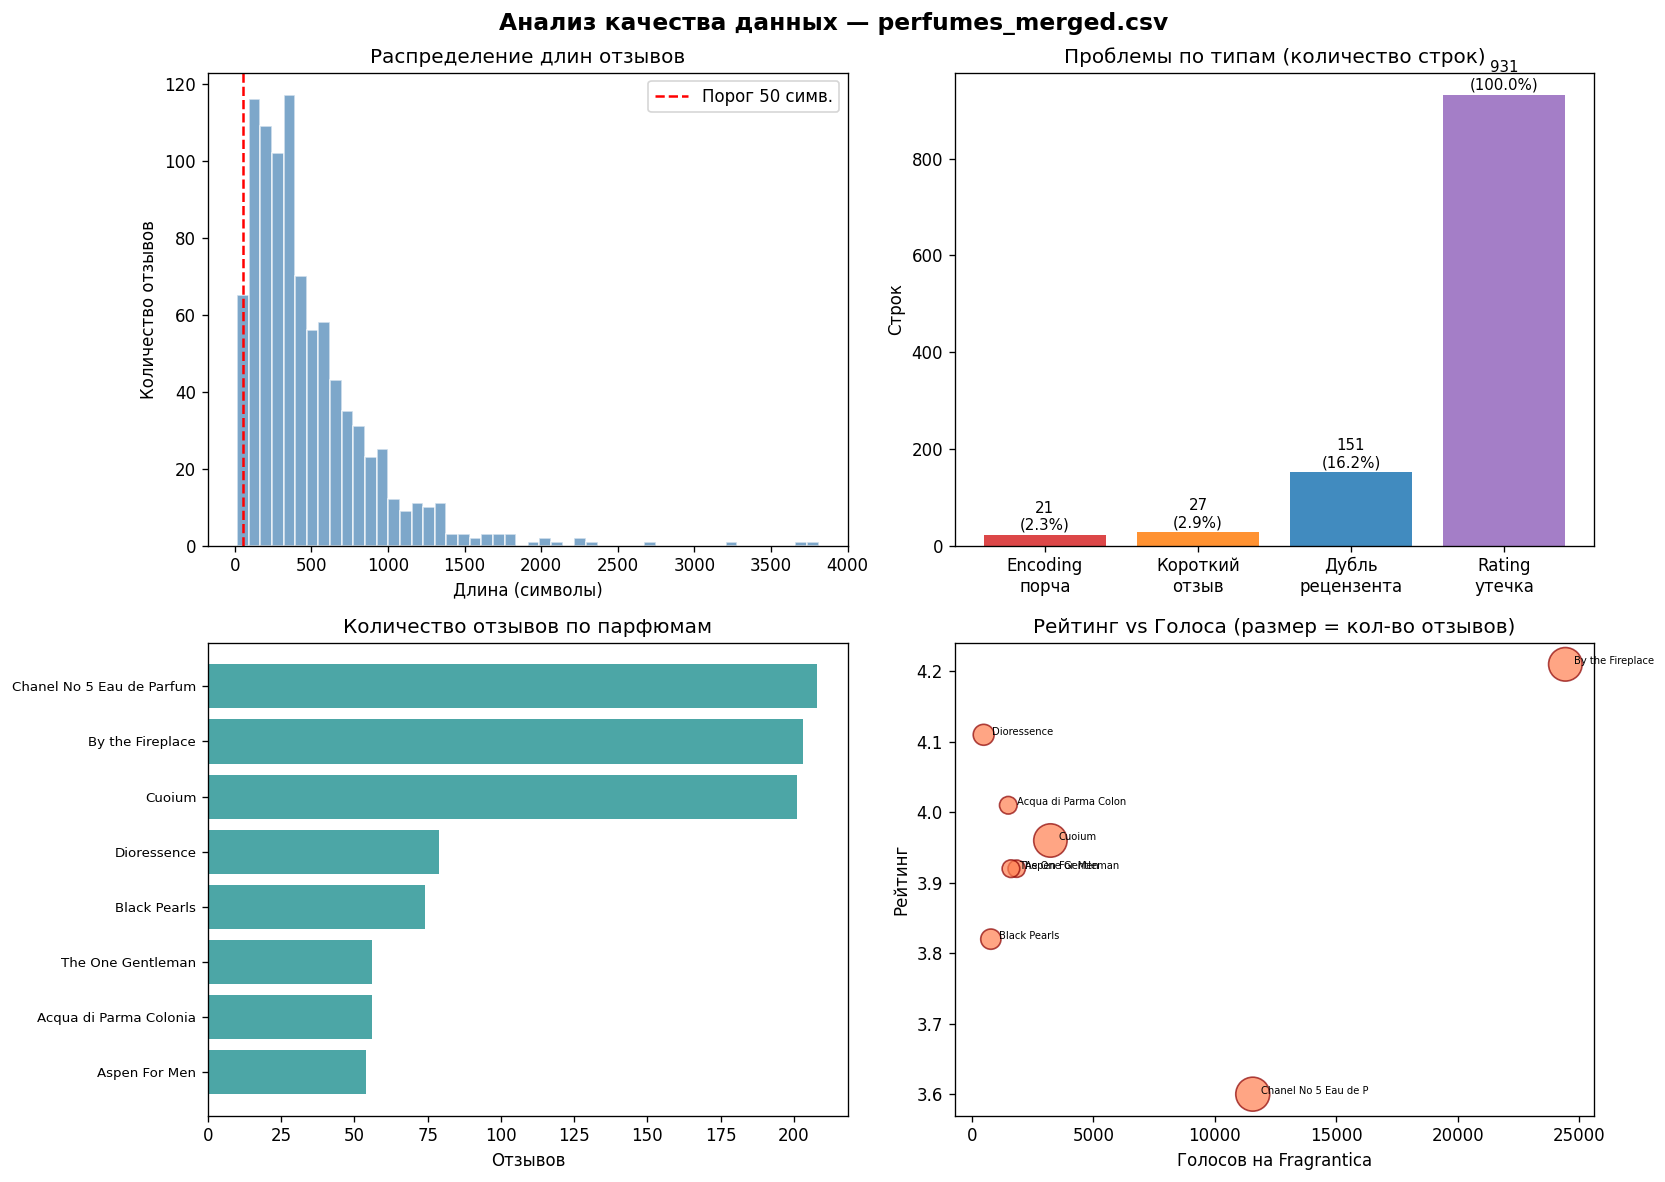

График сохранён: data/reports/fig_missing.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ качества данных — perfumes_merged.csv', fontsize=14, fontweight='bold')

# 1. Распределение длин отзывов
ax = axes[0, 0]
ax.hist(df['review_len'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Порог 50 симв.')
ax.set_title('Распределение длин отзывов')
ax.set_xlabel('Длина (символы)')
ax.set_ylabel('Количество отзывов')
ax.legend()

# 2. Обзор проблем по типам
ax = axes[0, 1]
n = len(df)
labels = ['Encoding\nпорча', 'Короткий\nотзыв', 'Дубль\nрецензента', 'Rating\nутечка']
counts = [enc_mask.sum(), short_only.sum(), dup_mask.sum(), n if is_leakage else 0]
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#9467bd']
bars = ax.bar(labels, counts, color=colors, alpha=0.85)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{cnt}\n({cnt/n*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Проблемы по типам (количество строк)')
ax.set_ylabel('Строк')

# 3. Распределение отзывов по парфюмам
ax = axes[1, 0]
perfume_counts = df.groupby('perfume_name').size().sort_values()
y_pos = range(len(perfume_counts))
ax.barh(y_pos, perfume_counts.values, color='teal', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([name[:30] for name in perfume_counts.index], fontsize=8)
ax.set_title('Количество отзывов по парфюмам')
ax.set_xlabel('Отзывов')

# 4. Рейтинг vs голоса
ax = axes[1, 1]
perfume_stats = df.groupby('perfume_name').agg({'rating': 'first', 'votes': 'first', 'review_text': 'count'}).reset_index()
sc = ax.scatter(perfume_stats['votes'], perfume_stats['rating'],
                s=perfume_stats['review_text'] * 2, alpha=0.7, c='coral', edgecolors='darkred')
for _, row in perfume_stats.iterrows():
    ax.annotate(row['perfume_name'][:20], (row['votes'], row['rating']),
                fontsize=6, ha='left', xytext=(5, 0), textcoords='offset points')
ax.set_title('Рейтинг vs Голоса (размер = кол-во отзывов)')
ax.set_xlabel('Голосов на Fragrantica')
ax.set_ylabel('Рейтинг')

plt.tight_layout()
plt.savefig('../data/reports/fig_missing.png', bbox_inches='tight')
plt.show()
print('График сохранён: data/reports/fig_missing.png')

## 8. Quality Score

In [9]:
report = compute_quality_score(df, 'review_text', 'reviewer', 'perfume_name', 'rating')
report['source_file'] = 'data/processed/perfumes_merged.csv'
report['task'] = 'sentiment_classification'

print(f'Quality Score: {report["quality_score"]}/100')
print(f'Итоговый штраф: -{report["total_penalty"]} баллов')
print()
print('Найденные проблемы:')
severity_icon = {'critical': '🔴', 'high': '🟠', 'medium': '🟡', 'low': '🟢'}
for issue in report['issues']:
    icon = severity_icon.get(issue['severity'], '⚪')
    print(f"  {icon} [{issue['severity'].upper():8s}] {issue['type']:30s} count={issue['count']:4d} ({issue['pct']:.1f}%) penalty=-{issue['penalty']}")
    print(f"            {issue['description']}")
    print()

Quality Score: 30.0/100
Итоговый штраф: -70.0 баллов

Найденные проблемы:
  🔴 [CRITICAL] encoding_corruption            count=  21 (2.3%) penalty=-30
            Текст отзыва содержит символы замены Unicode (\ufffd) — данные нечитаемы для NLP

  🟡 [MEDIUM  ] short_review                   count=  27 (2.9%) penalty=-15
            Отзыв слишком короткий (<50 символов) — мало информации для NLP

  🟠 [HIGH    ] duplicate_reviewer             count= 151 (16.2%) penalty=-15
            Один рецензент оставил несколько отзывов — риск утечки данных при train/test split

  🟠 [HIGH    ] perfume_level_rating           count=   8 (100.0%) penalty=-10.0
            'rating' — агрегат уровня парфюма, а не оценка отдельного отзыва; прямое использование как таргета приведёт к утечке



Отчёт сохранён: data\reports\quality_report.json


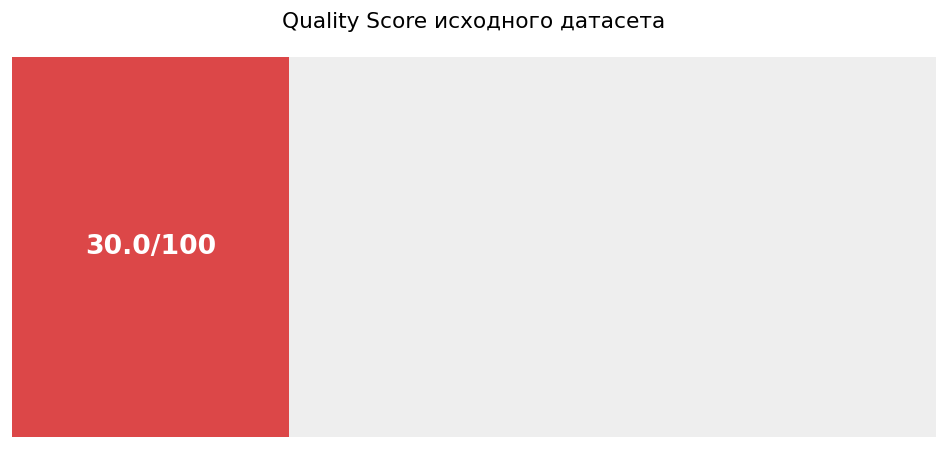

In [10]:
path = save_report(report)
print(f'Отчёт сохранён: {path}')

# Визуализация Quality Score
fig, ax = plt.subplots(figsize=(8, 4))
score = report['quality_score']
color = '#2ca02c' if score >= 80 else '#ff7f0e' if score >= 60 else '#d62728'
ax.barh(['Quality Score'], [score], color=color, alpha=0.85, height=0.4)
ax.barh(['Quality Score'], [100 - score], left=[score], color='#eeeeee', height=0.4)
ax.text(score / 2, 0, f'{score}/100', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
ax.set_xlim(0, 100)
ax.set_title('Quality Score исходного датасета', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/reports/fig_quality_score.png', bbox_inches='tight')
plt.show()